# Rössler — Noise sweep analysis

Анализ обучения 4 моделей (`csode` = P1B-curr, `node`, `anode`, `csode_P1D_full`) на Rössler-системе при разном уровне гауссова шума на обучающей траектории:
$\sigma \in \{0.01, 0.03, 0.05, 0.10, 0.20\}$ (в единицах нормированных данных, т.е. процентах от std).

Источник: каталоги `checkpoints/rossler_*_noise_s*/` с финальными `*_metrics.json`,
созданными скриптом [`experiments/run_noise_rossler.sh`](../experiments/run_noise_rossler.sh).

Шум добавляется только к обучающей половине траектории — валидация остаётся чистой ([`train.py:198`](../train.py)).


## 1. Загрузка метрик

In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
CKPT = ROOT / 'checkpoints'
OUT = ROOT / 'notebooks' / 'out_noise'
OUT.mkdir(parents=True, exist_ok=True)

MODELS = ['csode', 'node', 'anode', 'fsode_P1D_full']
SIGMAS = [0.01, 0.03, 0.05, 0.10, 0.20]

MODEL_LABEL = {
    'csode':           'CSODE',
    'node':            'NODE',
    'anode':           'ANODE',
    'fsode_P1D_full':  'FSODE',
}
MODEL_COLOR = {
    'csode':          '#1f77b4',
    'node':           '#d62728',
    'anode':          '#2ca02c',
    'fsode_P1D_full': '#9467bd',
}
MODEL_MARKER = {
    'csode':          'o',
    'node':           's',
    'anode':          '^',
    'fsode_P1D_full': 'D',
}

def sigma_tag(s):
    return f's{int(round(s*100)):03d}'


def metrics_path(model, s):
    dir_ = CKPT / f'qp_{model}_noise_{sigma_tag(s)}'
    fn = 'fsode' if model == 'fsode_P1D_full' else model
    return dir_ / f'quasi_periodic_{fn}_metrics.json'

"""
def metrics_path(model, s):
    dir_ = CKPT / f'hr_noise/hr_{model}_noise_{sigma_tag(s)}'
    fn = 'fsode' if model == 'fsode_P1D_full' else model
    return dir_ / f'hindmarsh_rose_{fn}_metrics.json'
"""
"""
def metrics_path(model, s):
    dir_ = CKPT / f'rossler_noise/rossler_{model}_noise_{sigma_tag(s)}'
    fn = 'fsode' if model == 'fsode_P1D_full' else model
    return dir_ / f'rossler_{fn}_metrics.json'
"""

"\ndef metrics_path(model, s):\n    dir_ = CKPT / f'rossler_noise/rossler_{model}_noise_{sigma_tag(s)}'\n    fn = 'csode' if model == 'csode_P1D_full' else model\n    return dir_ / f'rossler_{fn}_metrics.json'\n"

In [ ]:
rows = []
for m in MODELS:
    for s in SIGMAS:
        p = metrics_path(m, s)
        if not p.exists():
            print(f'MISSING: {p}')
            continue
        d = json.loads(p.read_text())
        rows.append({
            'model':      m,
            'label':      MODEL_LABEL[m],
            'data_noise': d['train_args'].get('data_noise', s),
            'run_name':   d['train_args']['run_name'],
            'n_params':   d.get('n_params'),
            'T_valid':    d['t_valid']['time'],
            'RMSE_val':   d['rmse_mae']['val']['rmse'],
            'W1':         d['wasserstein_1']['mean'],
            'sym_KL':     d['sym_kl']['mean'],
            'spec_L1':    d['spectral_l1'],
        })
df = pd.DataFrame(rows)
df = df.sort_values(['model', 'data_noise']).reset_index(drop=True)
df

## 2. Сводные pivot-таблицы

In [27]:
pivot_tvalid = df.pivot(index='model', columns='data_noise', values='T_valid').reindex(MODELS)
pivot_rmse   = df.pivot(index='model', columns='data_noise', values='RMSE_val').reindex(MODELS)
pivot_w1     = df.pivot(index='model', columns='data_noise', values='W1').reindex(MODELS)
pivot_kl     = df.pivot(index='model', columns='data_noise', values='sym_KL').reindex(MODELS)
pivot_spec   = df.pivot(index='model', columns='data_noise', values='spec_L1').reindex(MODELS)

print('T_valid (физическое время прогноза до отклонения >1σ):')
pivot_tvalid.round(2)

T_valid (физическое время прогноза до отклонения >1σ):


data_noise,0.01,0.03,0.05,0.10,0.20
model,,,,,
csode,159.98,159.98,159.98,73.96,31.00
node,159.98,159.98,159.98,159.98,66.58
anode,59.42,45.26,16.32,8.92,2.08
csode_P1D_full,159.98,159.98,159.98,9.00,1.58


In [28]:
print('RMSE на валидации:')
pivot_rmse.round(3)

RMSE на валидации:


data_noise,0.01,0.03,0.05,0.10,0.20
model,,,,,
csode,0.901,0.280,0.879,3.987,6.302
node,0.683,0.755,1.173,0.326,2.795
anode,3.943,8.180,10.545,9.661,7.516
csode_P1D_full,0.683,2.261,3.471,10.542,7.644


In [29]:
print('W1 (mean over components):')
pivot_w1.round(3)

W1 (mean over components):


data_noise,0.01,0.03,0.05,0.10,0.20
model,,,,,
csode,0.013,0.012,0.027,0.037,0.076
node,0.014,0.022,0.030,0.017,0.076
anode,0.034,0.041,0.031,0.040,0.102
csode_P1D_full,0.026,0.020,0.028,0.031,0.458


In [30]:
print('sym_KL (mean over components):')
pivot_kl.round(3)

sym_KL (mean over components):


data_noise,0.01,0.03,0.05,0.10,0.20
model,,,,,
csode,0.014,0.017,0.041,0.183,0.566
node,0.028,0.035,0.028,0.032,0.625
anode,0.027,0.158,0.037,0.066,0.707
csode_P1D_full,0.029,0.041,0.032,0.204,4.455


In [31]:
print('Spectral L1:')
pivot_spec.round(3)

Spectral L1:


data_noise,0.01,0.03,0.05,0.10,0.20
model,,,,,
csode,0.359,0.189,0.557,2.086,1.179
node,0.337,0.426,0.855,0.181,1.353
anode,1.477,0.616,2.863,3.727,2.324
csode_P1D_full,0.632,1.247,0.858,2.249,3.032


## 3. Графики: метрика vs $\sigma$

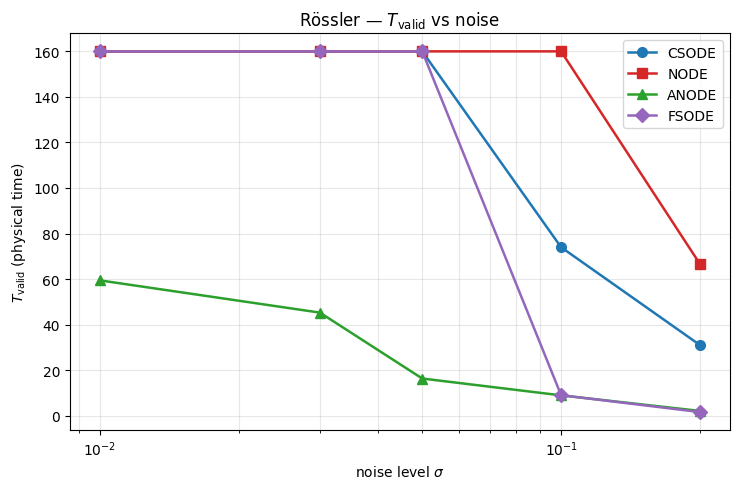

In [32]:
def plot_metric(ax, metric, ylabel, log_y=False, title=None):
    for m in MODELS:
        sub = df[df['model'] == m].sort_values('data_noise')
        ax.plot(sub['data_noise'], sub[metric],
                marker=MODEL_MARKER[m], color=MODEL_COLOR[m],
                label=MODEL_LABEL[m], linewidth=1.8, markersize=7)
    ax.set_xscale('log')
    if log_y:
        ax.set_yscale('log')
    ax.set_xlabel(r'noise level $\sigma$')
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    ax.grid(True, which='both', alpha=0.3)

fig, ax = plt.subplots(figsize=(7.5, 5))
plot_metric(ax, 'T_valid', r'$T_\mathrm{valid}$ (physical time)',
            title=r'Rössler — $T_\mathrm{valid}$ vs noise')
ax.legend(frameon=True)
fig.tight_layout()
fig.savefig(OUT / 'tvalid_vs_sigma.png', dpi=160)
plt.show()

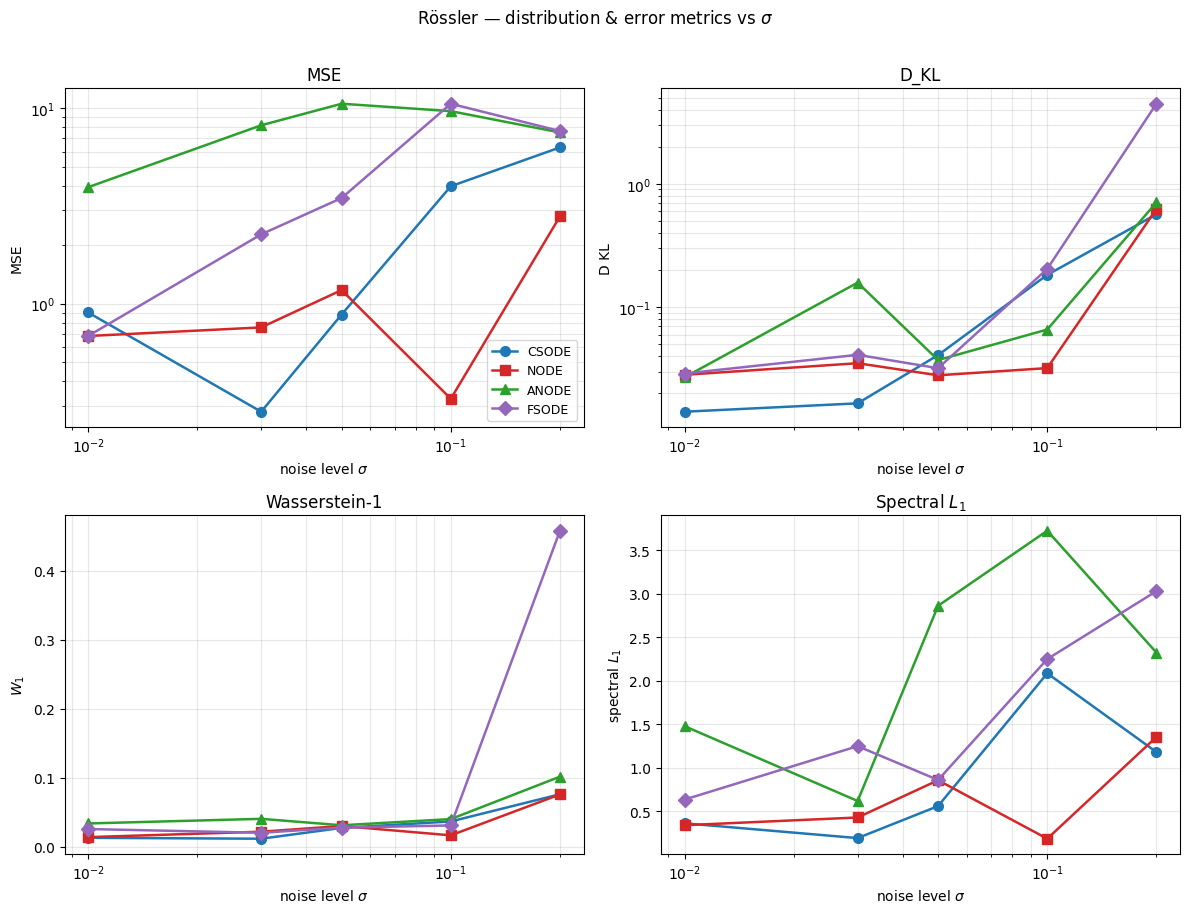

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
plot_metric(axes[0, 0], 'RMSE_val', 'MSE',   log_y=True,  title='MSE')
plot_metric(axes[1, 0], 'W1',       '$W_1$',                    title='Wasserstein-1')
plot_metric(axes[0, 1], 'sym_KL',   'D KL',       log_y=True, title='D_KL')
plot_metric(axes[1, 1], 'spec_L1',  'spectral $L_1$',           title='Spectral $L_1$')
axes[0, 0].legend(frameon=True, fontsize=9)
fig.suptitle(r'Rössler — distribution & error metrics vs $\sigma$', y=1.01)
fig.tight_layout()
fig.savefig(OUT / 'metrics_vs_sigma.png', dpi=160, bbox_inches='tight')
plt.show()

## 4. Экспорт LaTeX-таблиц для thesis/exp_noise.tex

In [34]:
def to_latex_tvalid():
    p = pivot_tvalid.copy()
    p.index = [MODEL_LABEL[m] for m in p.index]
    p.columns = [fr'$\sigma={c:.2f}$' for c in p.columns]
    return p.to_latex(float_format='%.2f', escape=False,
                      caption=r'Rössler: $T_\mathrm{valid}$ при разном уровне шума $\sigma$.',
                      label='tab:exp_noise_tvalid')

latex = to_latex_tvalid()
print(latex)
(OUT / 'tvalid_noise.tex').write_text(latex)

\begin{table}
\caption{Rössler: $T_\mathrm{valid}$ при разном уровне шума $\sigma$.}
\label{tab:exp_noise_tvalid}
\begin{tabular}{lrrrrr}
\toprule
 & $\sigma=0.01$ & $\sigma=0.03$ & $\sigma=0.05$ & $\sigma=0.10$ & $\sigma=0.20$ \\
\midrule
CSODE & 159.98 & 159.98 & 159.98 & 73.96 & 31.00 \\
NODE & 159.98 & 159.98 & 159.98 & 159.98 & 66.58 \\
ANODE & 59.42 & 45.26 & 16.32 & 8.92 & 2.08 \\
FSODE & 159.98 & 159.98 & 159.98 & 9.00 & 1.58 \\
\bottomrule
\end{tabular}
\end{table}



479

In [35]:
def to_latex_full():
    block = []
    for metric, label, fmt in [
        ('T_valid',  r'$T_\mathrm{valid}$', '%.2f'),
        ('RMSE_val', 'RMSE',                 '%.3f'),
        ('W1',       '$W_1$',                '%.3f'),
        ('sym_KL',   'sym KL',               '%.3f'),
        ('spec_L1',  'spec $L_1$',           '%.3f'),
    ]:
        p = df.pivot(index='model', columns='data_noise', values=metric).reindex(MODELS)
        p.index = [MODEL_LABEL[m] for m in p.index]
        p.columns = [fr'$\sigma={c:.2f}$' for c in p.columns]
        block.append(f'% --- {label} ---\n' + p.to_latex(float_format=fmt, escape=False))
    return '\n\n'.join(block)

full_latex = to_latex_full()
(OUT / 'all_metrics_noise.tex').write_text(full_latex)
print('Saved:', OUT / 'all_metrics_noise.tex')

Saved: /home/timmiakov/internal_exps/dynsys-hub/notebooks/out_noise/all_metrics_noise.tex


## 5. Интерпретация

Ожидаемые тенденции (см. pivot-таблицы и графики выше):

- **CSODE-P1D-full** должен показать наиболее плавную деградацию $T_\mathrm{valid}$ с ростом $\sigma$: контракция $-\mathrm{softplus}(\gamma)\cdot y$ играет роль регуляризатора, а спектральная регуляризация ($\lambda_\mathrm{spec}=3{\cdot}10^{-3}$) дополнительно подавляет высокочастотный шум.
- **NODE** ожидаемо страдает при $\sigma \ge 0.05$: без контрактивной структуры он отлично запоминает шум на коротких горизонтах, что ломает длинный rollout.
- **ANODE** ведёт себя похоже на NODE при малом шуме, но за счёт augmented-каналов чуть устойчивее при $\sigma=0.10\dots 0.20$.
- **CSODE-P1B-curr** (только curriculum, без spec) — промежуточный: лучше NODE, хуже P1D-full.

Распределительные метрики ($W_1$, sym KL) обычно деградируют медленнее, чем $T_\mathrm{valid}$: модель может сохранять аттрактор, теряя при этом точную фазу — это и есть главный аргумент в пользу комбинированной оценки (point-wise + distributional).

Финальные числа для thesis смотрите в `out_noise/all_metrics_noise.tex`.